In [1]:
#imports
import numpy as np
from utils import objects as ob
from utils import soa as SOA

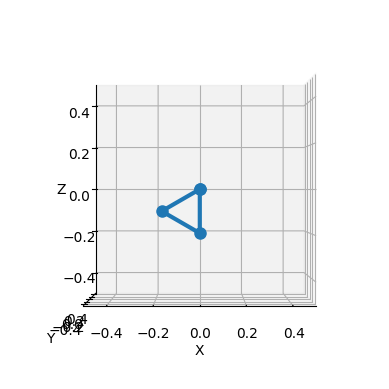

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>)

In [ ]:
#intializing multibodysystem
robot_sph = ob.MultiBodySystem()

#defining joints
joint3 = ob.SphericalJoint()
joint2 = ob.SphericalJoint()
joint1 = ob.SphericalJoint()

#intialziing such that pendulum is hanging to the right
joint3.q_init = SOA.quatfromrev(1*np.pi, "y")
joint2.q_init = SOA.quatfromrev(2*np.pi/3, "y")
joint1.q_init = SOA.quatfromrev(2*np.pi/3, "y")

#defining link
link3 = ob.Link(mass=1.0, l_hinge=np.array([0, 0, 0.2]), joint=joint3)
link2 = ob.Link(mass=1.0, l_hinge=np.array([0, 0, 0.2]), joint=joint2)
link1 = ob.Link(mass=1.0, l_hinge=np.array([0, 0, 0.2]), joint=joint1)

#adding link (first link is added to the base, second link is added to the first link and so on)
robot_sph.add_link(link3)
robot_sph.add_link(link2)
robot_sph.add_link(link1)

#parameters for simulation
tspan = np.arange(0,5,0.001)

V_base = np.zeros(6)
A_base = np.zeros(6)
A_base[-1] = 9.81 #simulating gravity in z

In [3]:
robot_sph.simulate(tspan,V_base,A_base,"closed",BG_params=[2000,2500])

Simulation started (closed-loop configuration)
t = 0.00 s
t = 1.00 s
t = 2.00 s
t = 2.00 s
t = 3.00 s
t = 3.00 s
t = 4.00 s
Simulation finished


In [ ]:
#REVOLUTE IMPLEMENTATION
#intializing multibodysystem
robot_rev = ob.MultiBodySystem()

#defining joints
joint3 = ob.RevoluteJoint(axis="x")
joint2 = ob.RevoluteJoint(axis="y")
joint1 = ob.RevoluteJoint(axis="z")

#intialziing such that pendulum is hanging to the right
joint3.q_init = np.array([1*np.pi])
joint2.q_init = np.array([2*np.pi/3])
joint1.q_init = np.array([2*np.pi/3])

#defining link
link3 = ob.Link(mass=1.0, l_hinge=np.array([0, 0, 0.2]), joint=joint3)
link2 = ob.Link(mass=1.0, l_hinge=np.array([0, 0, 0.2]), joint=joint2)
link1 = ob.Link(mass=1.0, l_hinge=np.array([0, 0, 0.2]), joint=joint1)

#adding link (first link is added to the base, second link is added to the first link and so on)
robot_rev.add_link(link3)
robot_rev.add_link(link2)
robot_rev.add_link(link1)

#parameters for simulation
tspan = np.arange(0,5,0.001)

V_base = np.zeros(6)
A_base = np.zeros(6)
A_base[-1] = 9.81 #simulating gravity in z

In [7]:
robot_rev.simulate(tspan,V_base,A_base,"closed",BG_params=[2000,2500])

Simulation started (closed-loop configuration)
t = 0.00 s
t = 1.00 s
t = 2.00 s
t = 2.00 s
t = 3.00 s
t = 3.00 s
t = 4.00 s
Simulation finished


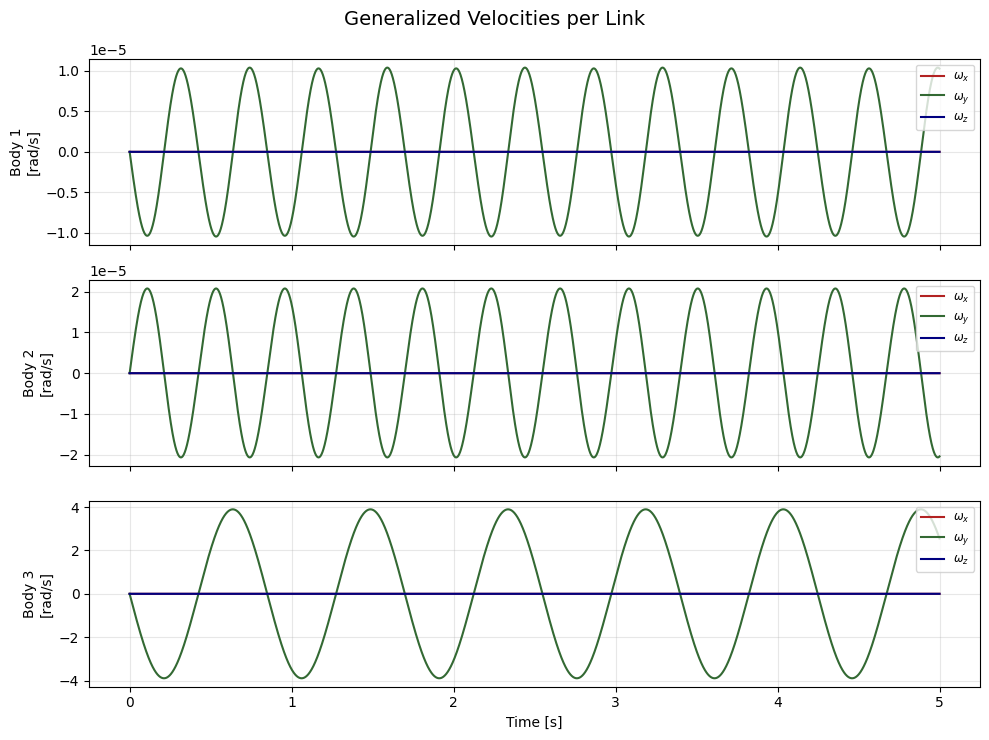

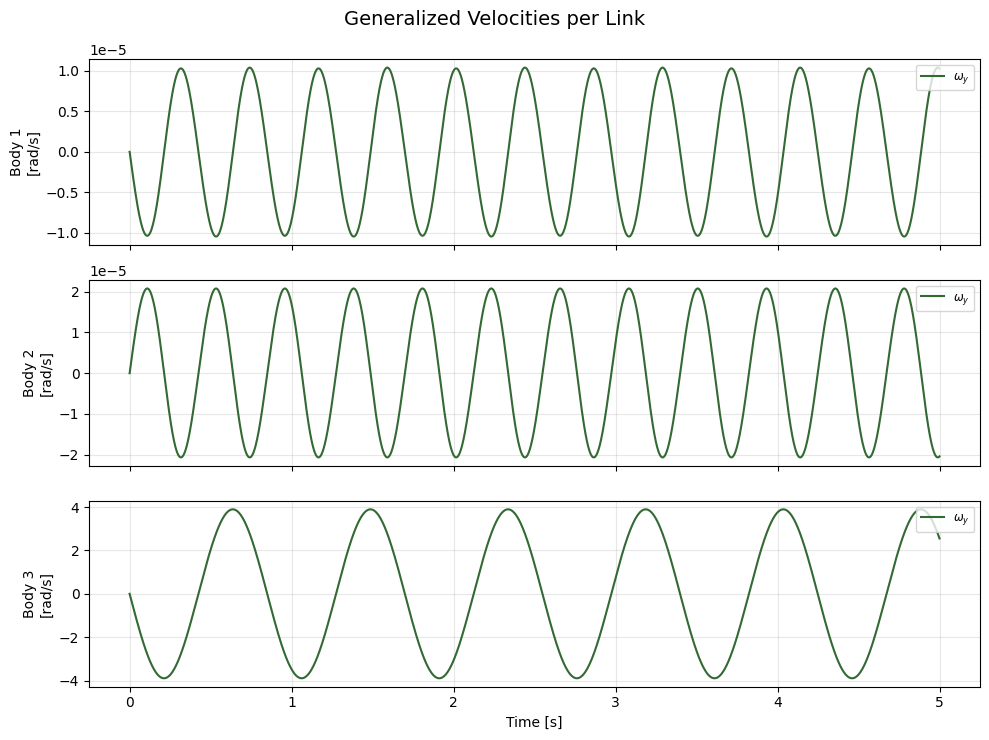

In [18]:
robot_sph.plot_gen_velocities()
robot_rev.plot_gen_velocities()